[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duoan/TorchCode/blob/master/templates/19_gelu.ipynb)

# 🟢 Easy: GELU Activation

Implement the **GELU** (Gaussian Error Linear Unit) activation.

$$\text{GELU}(x) = x \cdot \Phi(x) = x \cdot 0.5 \cdot (1 + \text{erf}(x / \sqrt{2}))$$

### Signature
```python
def my_gelu(x: Tensor) -> Tensor: ...
```

### Rules
- Do NOT use `F.gelu`, `nn.GELU`, or `torch.nn.functional.gelu`
- Use `torch.erf` for the exact version

In [1]:
# Install torch-judge in Colab (no-op in JupyterLab/Docker)
try:
    import google.colab
    get_ipython().run_line_magic('pip', 'install -q torch-judge')
except ImportError:
    pass


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 1.8 MB/s eta 0:00:00


In [2]:
import torch
import math

In [7]:
# ✏️ YOUR IMPLEMENTATION HERE

def phi (x):
  return 0.5*(torch.ones_like(x)+torch.erf(x/math.sqrt(2)))
def my_gelu(x):
  return x*phi(x)


In [8]:
# 🧪 Debug
x = torch.tensor([-2., -1., 0., 1., 2.])
print('Output:', my_gelu(x))
print('Ref:   ', torch.nn.functional.gelu(x))

Output: tensor([-0.0455, -0.1587,  0.0000,  0.8413,  1.9545])
Ref:    tensor([-0.0455, -0.1587,  0.0000,  0.8413,  1.9545])


In [9]:
# ✅ SUBMIT
from torch_judge import check
check('gelu')


🧪 Testing: GELU Activation (Easy)
──────────────────────────────────────────────────
  ✅ [1/4] Matches F.gelu (23.4ms)
  ✅ [2/4] gelu(0) = 0 (0.5ms)
  ✅ [3/4] Shape preservation (0.2ms)
  ✅ [4/4] Gradient flow (23.0ms)
──────────────────────────────────────────────────
  🎉 All 4 tests passed! (47.1ms total)
  Progress saved. Run status() to see your dashboard.



# Notes

# Chat GPT implementation


In [10]:
def phi(x):
    return 0.5 * (1 + torch.erf(x / math.sqrt(2)))

## GELU Interview Questions (10)

1. **What is the GELU activation function? Write its mathematical definition.**

2. **How does GELU differ from ReLU and why might it perform better in some models?**

3. **What is the intuition behind GELU in terms of probabilistic interpretation?**

4. **Why is the error function (`erf`) used in the exact GELU formulation?**

5. **What is the difference between the exact GELU and the tanh-based approximation? Why is the approximation often used in practice?**

6. **Is GELU differentiable everywhere? How does this compare to ReLU?**

7. **Where is GELU commonly used in modern deep learning architectures? Why is it preferred there?**

8. **How would you implement GELU from scratch in PyTorch? What are the key considerations?**

9. **What are the computational trade-offs of using GELU compared to simpler activations like ReLU?**

10. **How does GELU affect gradient flow and training stability compared to ReLU or sigmoid activations?**

## GELU Interview Questions — Answers

1. **What is the GELU activation function? Write its mathematical definition.**  
GELU stands for **Gaussian Error Linear Unit**. It is defined as:
\[
\mathrm{GELU}(x) = x \Phi(x)
\]
where \(\Phi(x)\) is the cumulative distribution function (CDF) of the standard normal distribution. In exact form:
\[
\mathrm{GELU}(x) = x \cdot \frac{1}{2}\left(1 + \mathrm{erf}\left(\frac{x}{\sqrt{2}}\right)\right)
\]

---

2. **How does GELU differ from ReLU and why might it perform better in some models?**  
ReLU is a hard thresholding function:
\[
\mathrm{ReLU}(x) = \max(0, x)
\]
It completely zeros out all negative inputs. GELU, in contrast, smoothly scales inputs based on their value, including small negative values. This smoothness can make optimization easier and can preserve more information, which is one reason GELU often performs well in transformer models.

---

3. **What is the intuition behind GELU in terms of probabilistic interpretation?**  
GELU can be interpreted as weighting an input by the probability that it should be kept. Instead of deterministically keeping all positive values and discarding all negative ones, GELU gates inputs smoothly according to the Gaussian CDF. Large positive values are mostly preserved, large negative values are mostly suppressed, and values near zero are partially retained.

---

4. **Why is the error function (`erf`) used in the exact GELU formulation?**  
The error function appears because the standard normal CDF can be written in terms of `erf`. Since GELU is defined using the Gaussian CDF, the exact closed-form expression naturally uses:
\[
\Phi(x)=\frac{1}{2}\left(1+\mathrm{erf}\left(\frac{x}{\sqrt{2}}\right)\right)
\]

---

5. **What is the difference between the exact GELU and the tanh-based approximation? Why is the approximation often used in practice?**  
The exact GELU uses the error function:
\[
x \cdot \frac{1}{2}\left(1+\mathrm{erf}\left(\frac{x}{\sqrt{2}}\right)\right)
\]
A common approximation is:
\[
0.5x\left(1+\tanh\left(\sqrt{\frac{2}{\pi}}(x+0.044715x^3)\right)\right)
\]
The approximation is often used because it is computationally cheaper while remaining very close to the exact function.

---

6. **Is GELU differentiable everywhere? How does this compare to ReLU?**  
Yes, GELU is differentiable everywhere because it is a smooth function composed of differentiable operations. ReLU is not differentiable at \(x=0\), though in practice this is usually handled without issue by autograd frameworks.

---

7. **Where is GELU commonly used in modern deep learning architectures? Why is it preferred there?**  
GELU is commonly used in **transformers** and large language models such as BERT and many GPT-style architectures. It is preferred because its smooth nonlinear behavior often works well in deep networks and can improve optimization and model quality compared with harsher activations like ReLU.

---

8. **How would you implement GELU from scratch in PyTorch? What are the key considerations?**  
A basic exact implementation is:
```python
def phi(x):
    return 0.5 * (1 + torch.erf(x / math.sqrt(2)))

def my_gelu(x):
    return x * phi(x)


9. **What are the computational trade-offs of using GELU compared to simpler activations like ReLU?**
ReLU is extremely cheap to compute because it only requires a max operation. GELU is more expensive because it uses erf or a tanh-based approximation. The trade-off is that GELU may improve performance and training behavior, especially in transformer-style models, at the cost of somewhat higher computation.
10. **How does GELU affect gradient flow and training stability compared to ReLU or sigmoid activations?**
Compared to ReLU, GELU provides smoother gradients, especially around zero, which can help optimization. Compared to sigmoid, GELU avoids strong saturation in the same way sigmoid does, so it generally supports better gradient flow in deep networks. This makes GELU a strong middle ground: smoother than ReLU, but more optimization-friendly than sigmoid.

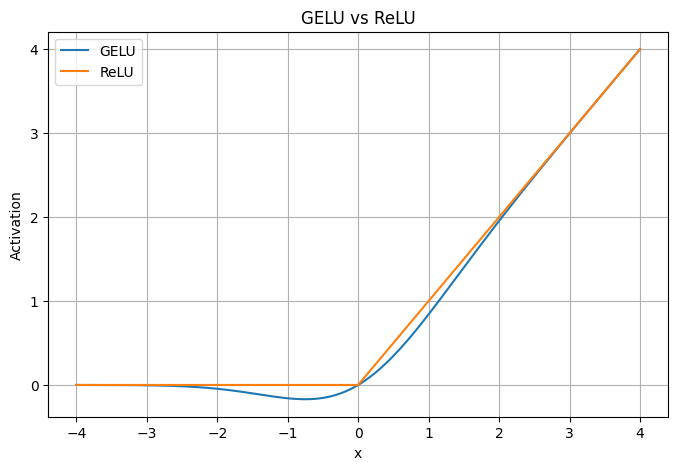

In [12]:

import math
import torch
import matplotlib.pyplot as plt

def gelu(x):
    return x * 0.5 * (1 + torch.erf(x / math.sqrt(2)))

def relu(x):
    return torch.maximum(x, torch.zeros_like(x))

x = torch.linspace(-4, 4, 400)
y_gelu = gelu(x)
y_relu = relu(x)

plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), y_gelu.numpy(), label="GELU")
plt.plot(x.numpy(), y_relu.numpy(), label="ReLU")
plt.xlabel("x")
plt.ylabel("Activation")
plt.title("GELU vs ReLU")
plt.legend()
plt.grid(True)
plt.show()